## Descripción del dataset

El archivo `weatherAUS_2026C2.csv` tiene una fila por día y por ciudad con las mediciones del clima de Australia. Estas son sus columnas:

| Columna | Descripción |
|---|---|
| `Date` | Fecha de la observación. |
| `Location` | Ciudad donde se hizo la observación. |
| `MinTemp` | Temperatura mínima del día (°C). |
| `MaxTemp` | Temperatura máxima del día (°C). |
| `Rainfall` | Lluvia total registrada en el día (mm). |
| `Evaporation` | Evaporación total registrada en el día (mm). |
| `Sunshine` | Horas de sol del día. |
| `WindGustDir` | Dirección de la ráfaga de viento más fuerte del día. |
| `WindGustSpeed` | Velocidad de la ráfaga de viento más fuerte del día (km/h). |
| `WindDir9am` | Dirección del viento a las 9 h. |
| `WindDir3pm` | Dirección del viento a las 15 h. |
| `WindSpeed9am` | Velocidad del viento a las 9 h (km/h). |
| `WindSpeed3pm` | Velocidad del viento a las 15 h (km/h). |
| `Humidity9am` | Humedad a las 9 h (%). |
| `Humidity3pm` | Humedad a las 15 h (%). |
| `Pressure9am` | Presión atmosférica a las 9 h (hPa). |
| `Pressure3pm` | Presión atmosférica a las 15 h (hPa). |
| `Cloud9am` | Nubosidad a las 9 h (en octas: 0 es cielo despejado y 8, totalmente cubierto). |
| `Cloud3pm` | Nubosidad a las 15 h (en octas). |
| `Temp9am` | Temperatura a las 9 h (°C). |
| `Temp3pm` | Temperatura a las 15 h (°C). |
| `RainToday` | Si llovió en el día (`Yes` / `No`). |
| `RainTomorrow` | Si llovió al día siguiente (`Yes` / `No`). Es la variable objetivo. Yes si RainfallTomorrow es mayor a 1mm.|
| `RainfallTomorrow` | Lluvia registrada al día siguiente (mm). |


In [1]:
# Librerías y configuración de gráficos y tablas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [5]:
df_weather = pd.read_csv("./Data/weatherAUS_2026C2.csv", index_col=0)
df_weather.info()

<class 'pandas.DataFrame'>
Index: 145412 entries, 0 to 145458
Data columns (total 24 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Date              145412 non-null  str    
 1   Location          145412 non-null  str    
 2   MinTemp           143928 non-null  float64
 3   MaxTemp           144159 non-null  float64
 4   Rainfall          142152 non-null  float64
 5   Evaporation       82658 non-null   float64
 6   Sunshine          75616 non-null   float64
 7   WindGustDir       135096 non-null  str    
 8   WindGustSpeed     135159 non-null  float64
 9   WindDir9am        134850 non-null  str    
 10  WindDir3pm        141186 non-null  str    
 11  WindSpeed9am      143645 non-null  float64
 12  WindSpeed3pm      142351 non-null  float64
 13  Humidity9am       142759 non-null  float64
 14  Humidity3pm       140907 non-null  float64
 15  Pressure9am       130351 non-null  float64
 16  Pressure3pm       130388 non-null  f

In [6]:
df_weather.isnull().sum()

Date                    0
Location                0
MinTemp              1484
MaxTemp              1253
Rainfall             3260
Evaporation         62754
Sunshine            69796
WindGustDir         10316
WindGustSpeed       10253
WindDir9am          10562
WindDir3pm           4226
WindSpeed9am         1767
WindSpeed3pm         3061
Humidity9am          2653
Humidity3pm          4505
Pressure9am         15061
Pressure3pm         15024
Cloud9am            55870
Cloud3pm            59336
Temp9am              1766
Temp3pm              3607
RainToday            3260
RainTomorrow         3259
RainfallTomorrow     3259
dtype: int64

In [7]:
# Cantidad y porcentaje de nulos por columna
nulos = df_weather.isnull().sum()
pct_nulos = (nulos / len(df_weather)) * 100

reporte_nulos = pd.DataFrame({
    'Nulos': nulos,
    'Porcentaje (%)': pct_nulos,
    'Tipo': df_weather.dtypes
})

print('Reporte de Valores Nulos:')
print('=' * 50)
print(reporte_nulos)
print(f'\nTotal de celdas con nulos: {nulos.sum()} '
      f'({nulos.sum() / df_weather.size * 100:.4f}% del dataset)')

Reporte de Valores Nulos:
                  Nulos  Porcentaje (%)     Tipo
Date                  0        0.000000      str
Location              0        0.000000      str
MinTemp            1484        1.020549  float64
MaxTemp            1253        0.861690  float64
Rainfall           3260        2.241906  float64
Evaporation       62754       43.155998  float64
Sunshine          69796       47.998790  float64
WindGustDir       10316        7.094325      str
WindGustSpeed     10253        7.051000  float64
WindDir9am        10562        7.263500      str
WindDir3pm         4226        2.906225      str
WindSpeed9am       1767        1.215168  float64
WindSpeed3pm       3061        2.105053  float64
Humidity9am        2653        1.824471  float64
Humidity3pm        4505        3.098094  float64
Pressure9am       15061       10.357467  float64
Pressure3pm       15024       10.332022  float64
Cloud9am          55870       38.421863  float64
Cloud3pm          59336       40.805436  fl

In [8]:
df_nulos = df_weather[df_weather.isnull().any(axis=1)]
df_nulos

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,RainfallTomorrow
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
0,2008-12-01,Albury,13.6,22.5,0.6,NaN,NaN,W,45.0,W,...,23.8,1008.1,1007.2,8.0,NaN,16.8,20.8,No,No,0.0
1,2008-12-02,Albury,7.3,25.8,0.0,NaN,NaN,WNW,44.0,NNW,...,22.1,1011.1,1007.5,NaN,NaN,18.3,24.6,No,No,0.0
2,2008-12-03,Albury,13.2,26.2,0.0,NaN,NaN,WSW,46.0,W,...,31.5,1007.3,1009.4,NaN,2.0,21.2,23.4,No,No,0.0
3,2008-12-04,Albury,10.0,28.8,0.0,NaN,NaN,NE,23.0,SE,...,18.5,1017.6,1012.4,NaN,NaN,17.4,26.3,No,No,1.0
4,2008-12-05,Albury,17.4,32.4,1.0,NaN,NaN,W,41.0,ENE,...,34.6,1010.9,1005.9,7.0,8.0,17.9,29.1,No,No,0.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145454,2017-06-20,Uluru,2.6,22.0,0.0,NaN,NaN,E,29.0,ESE,...,26.5,1024.8,1021.2,NaN,NaN,10.1,21.6,No,No,0.0
145455,2017-06-21,Uluru,3.1,23.2,0.0,NaN,NaN,E,31.0,SE,...,24.7,1024.3,1020.5,NaN,NaN,11.1,21.5,No,No,0.0
145456,2017-06-22,Uluru,3.6,26.0,0.0,NaN,NaN,NNW,21.0,SE,...,21.4,1023.3,1018.4,NaN,NaN,11.8,24.5,No,No,0.0


In [12]:
df_weather_procesado = df_weather.dropna(subset= 'RainTomorrow')

In [13]:
nulos = df_weather_procesado.isnull().sum()
pct_nulos = (nulos / len(df_weather_procesado)) * 100

reporte_nulos = pd.DataFrame({
    'Nulos': nulos,
    'Porcentaje (%)': pct_nulos,
    'Tipo': df_weather_procesado.dtypes
})

print('Reporte de Valores Nulos:')
print('=' * 50)
print(reporte_nulos)
print(f'\nTotal de celdas con nulos: {nulos.sum()} '
      f'({nulos.sum() / df_weather_procesado.size * 100:.4f}% del dataset)')

Reporte de Valores Nulos:
                  Nulos  Porcentaje (%)     Tipo
Date                  0        0.000000      str
Location              0        0.000000      str
MinTemp             637        0.448109  float64
MaxTemp             322        0.226516  float64
Rainfall           1406        0.989075  float64
Evaporation       60812       42.779259  float64
Sunshine          67785       47.684537  float64
WindGustDir        9328        6.561944      str
WindGustSpeed      9268        6.519736  float64
WindDir9am        10009        7.041005      str
WindDir3pm         3776        2.656293      str
WindSpeed9am       1348        0.948274  float64
WindSpeed3pm       2629        1.849416  float64
Humidity9am        1774        1.247951  float64
Humidity3pm        3609        2.538814  float64
Pressure9am       14010        9.855578  float64
Pressure3pm       13977        9.832364  float64
Cloud9am          53641       37.734694  float64
Cloud3pm          57076       40.151105  fl

In [15]:
df_weather_procesado = df_weather_procesado.dropna(thresh=len(df_weather_procesado.columns)*0.5)
nulos = df_weather_procesado.isnull().sum()
pct_nulos = (nulos / len(df_weather_procesado)) * 100

reporte_nulos = pd.DataFrame({
    'Nulos': nulos,
    'Porcentaje (%)': pct_nulos,
    'Tipo': df_weather_procesado.dtypes
})

print('Reporte de Valores Nulos:')
print('=' * 50)
print(reporte_nulos)
print(f'\nTotal de celdas con nulos: {nulos.sum()} '
      f'({nulos.sum() / df_weather_procesado.size * 100:.4f}% del dataset)')

Reporte de Valores Nulos:
                  Nulos  Porcentaje (%)     Tipo
Date                  0        0.000000      str
Location              0        0.000000      str
MinTemp             373        0.263058  float64
MaxTemp             221        0.155860  float64
Rainfall           1281        0.903423  float64
Evaporation       60484       42.656248  float64
Sunshine          67448       47.567598  float64
WindGustDir        9039        6.374741      str
WindGustSpeed      8979        6.332426  float64
WindDir9am         9662        6.814111      str
WindDir3pm         3462        2.441570      str
WindSpeed9am       1051        0.741216  float64
WindSpeed3pm       2324        1.638997  float64
Humidity9am        1481        1.044473  float64
Humidity3pm        3309        2.333667  float64
Pressure9am       13685        9.651325  float64
Pressure3pm       13658        9.632283  float64
Cloud9am          53344       37.620774  float64
Cloud3pm          56736       40.012977  fl

In [16]:
df_weather_procesado.isnull().sum(axis=1).value_counts().sort_index()

0     56412
1     10764
2     18023
3      9607
4     28531
5      3639
6      9934
7      1801
8       964
9       393
10      290
11      679
12      757
Name: count, dtype: int64

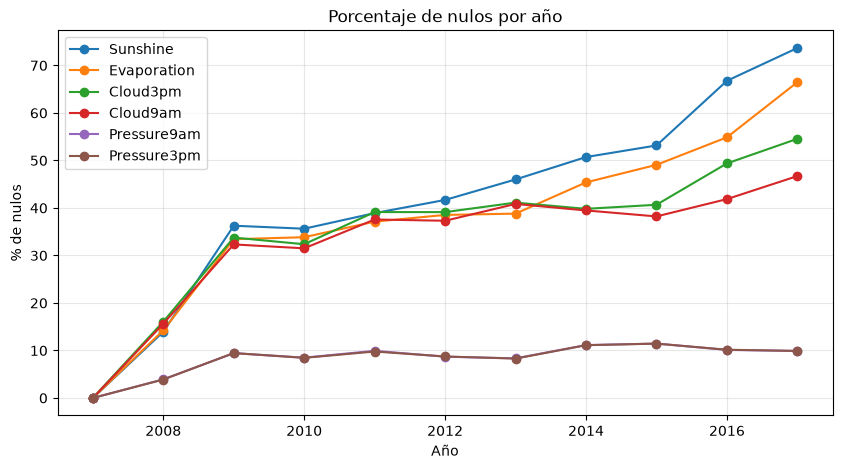

In [17]:
fecha = pd.to_datetime(df_weather_procesado["Date"])
cols_null = df_weather_procesado.isna().mean().sort_values(ascending=False).head(6).index

nulos_anio = df_weather_procesado[cols_null].isna().groupby(fecha.dt.year).mean() * 100
nulos_anio.plot(marker="o", figsize=(10, 5))
plt.xlabel("Año")
plt.ylabel("% de nulos")
plt.title("Porcentaje de nulos por año")
plt.grid(alpha=0.3)
plt.show()

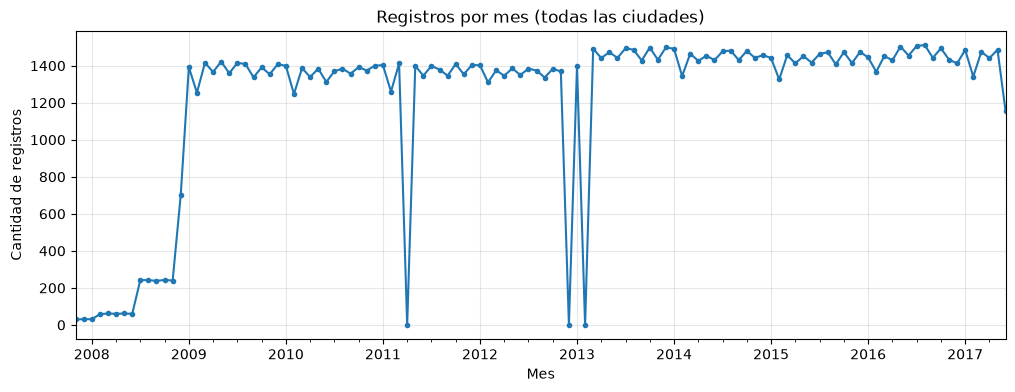

In [28]:
fecha = pd.to_datetime(df_weather_procesado["Date"])

registros_mes = fecha.dt.to_period("M").value_counts().sort_index()
registros_mes = registros_mes.reindex(pd.period_range(fecha.min(), fecha.max(), freq="M"), fill_value=0)
registros_mes.plot(figsize=(12, 4), marker=".")
plt.xlabel("Mes")
plt.ylabel("Cantidad de registros")
plt.title("Registros por mes (todas las ciudades)")
plt.grid(alpha=0.3)
plt.show()

In [24]:
columnas_numericas = df_weather_procesado.select_dtypes(include="number").columns

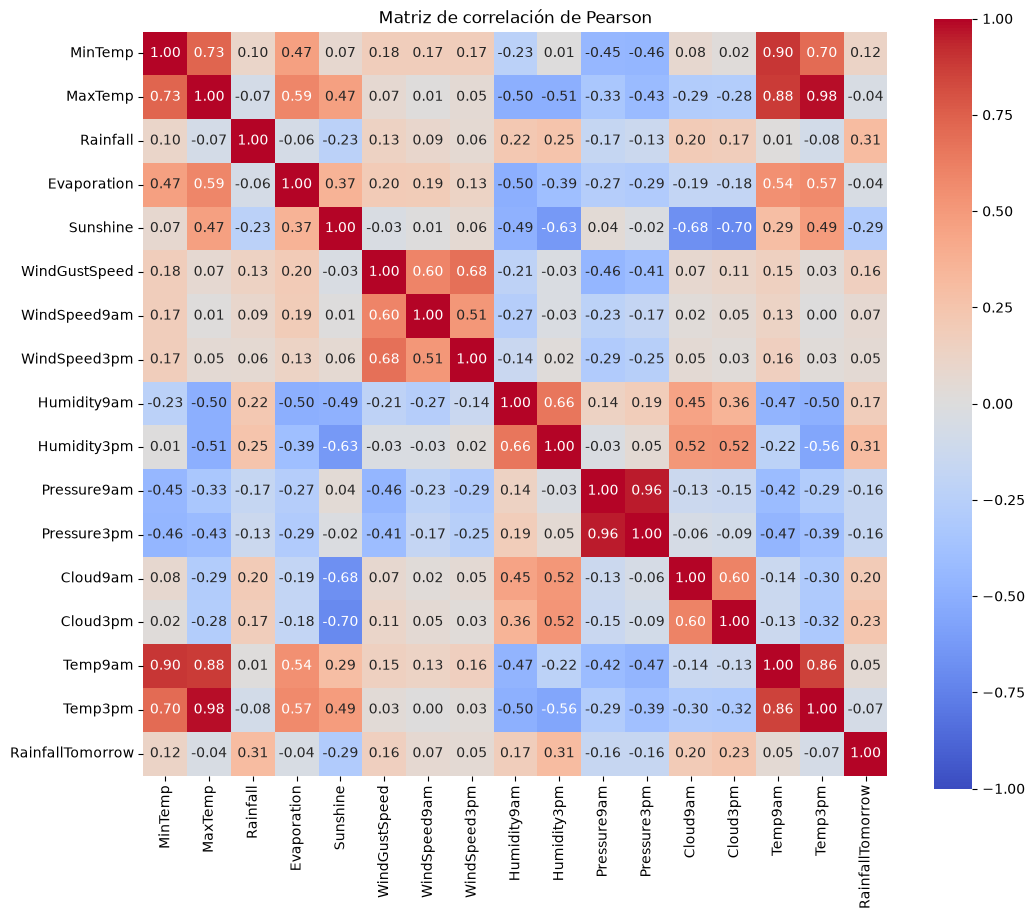

In [26]:
matriz_corr = df_weather_procesado[columnas_numericas].corr(method="pearson")

plt.figure(figsize=(12, 10))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Matriz de correlación de Pearson")
plt.show()

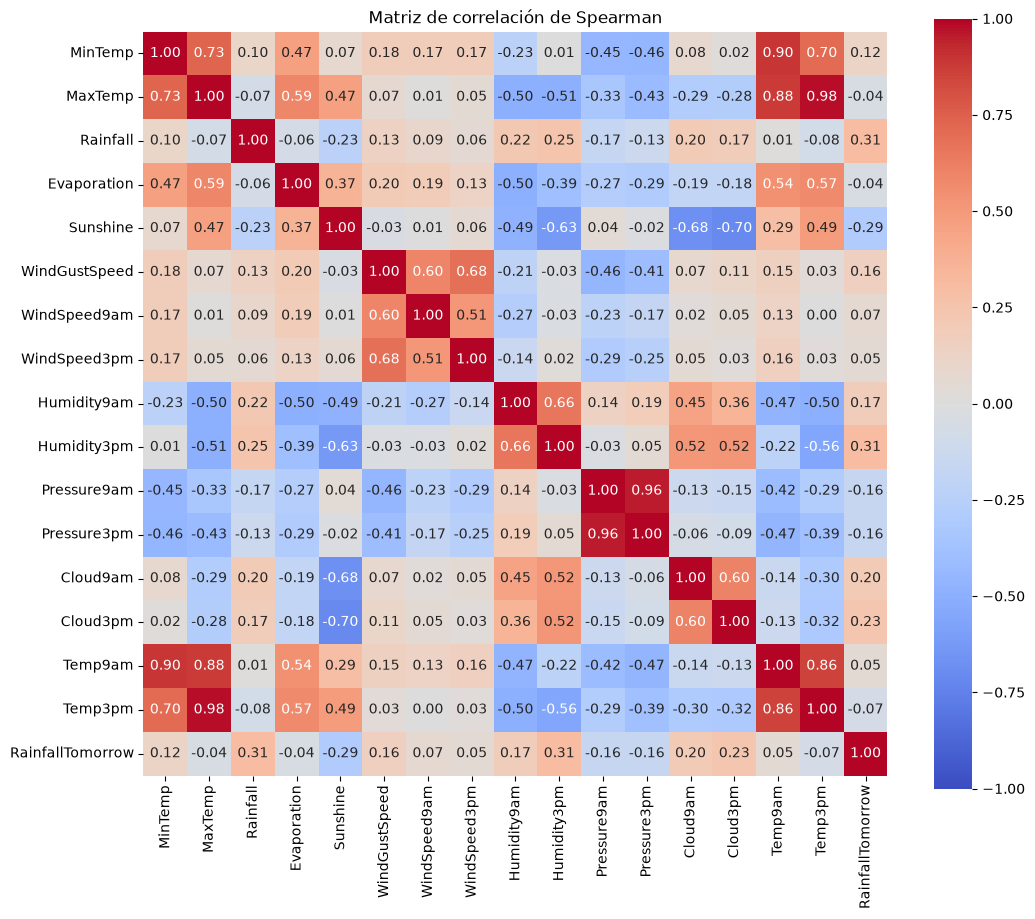

In [27]:
matriz_corr_spearman = df_weather_procesado[columnas_numericas].corr(method="spearman")

plt.figure(figsize=(12, 10))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Matriz de correlación de Spearman")
plt.show()